# 3.2 Logistic Regression Theory

## Table of Contents
- [3.2.1 Intuition & Sigmoid Function](#321-intuition--sigmoid-function)
- [3.2.2 Decision Boundary & Thresholding](#322-decision-boundary--thresholding)
- [3.2.3 Learning the Model Parameters](#323-learning-the-model-parameters)
- [3.2.4 Strengths and Limitations](#324-strengths-and-limitations)

## 3.2.1 Intuition & Sigmoid Function

Despite its name, Logistic Regression is actually used for **classification** problems, primarily binary classification. It serves as a fundamental algorithm and is often used as a baseline model before trying more complex approaches.

### Why Not Linear Regression for Classification?

Before diving into logistic regression, let's understand why we can't simply use linear regression for classification tasks:

1. **Unbounded Output Range**: Linear regression predicts continuous values that can be any real number, potentially outside the range of [0, 1]. For classification, we want a probability between 0 and 1.

2. **Inappropriate for Categorical Data**: Fitting a straight line to categorical (0/1) data doesn't make intuitive sense for finding a decision boundary. The line can produce predictions < 0 or > 1.

3. **Sensitivity to Outliers**: Linear regression minimizes squared errors, making it highly sensitive to outliers, which can be problematic for classification tasks.

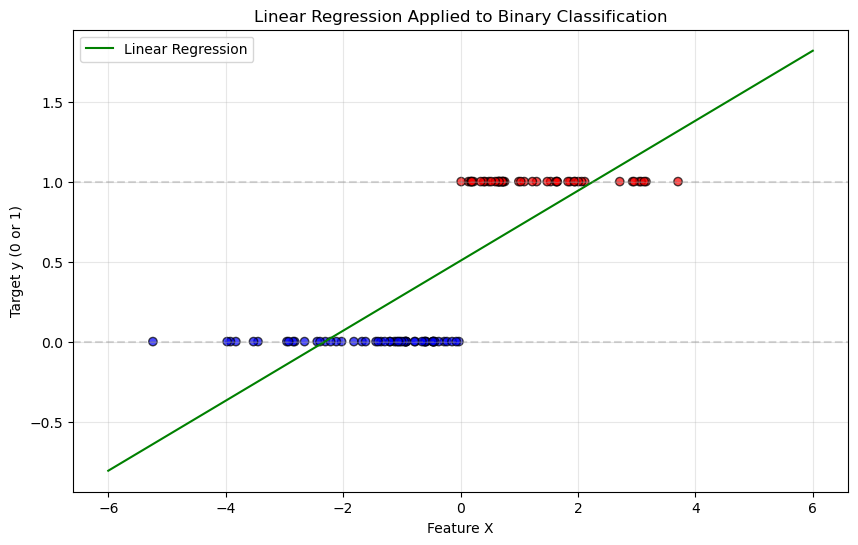

In [1]:
# Demonstration of why linear regression doesn't work well for classification
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import pandas as pd

# Generate sample data
np.random.seed(42)
X = np.random.randn(100, 1) * 2  # Feature
y = (X.squeeze() > 0).astype(int)  # Binary target (0 or 1)

# Fit linear regression
linear_model = LinearRegression()
linear_model.fit(X, y)
X_range = np.linspace(-6, 6, 100).reshape(-1, 1)
y_pred = linear_model.predict(X_range)

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, c=y, cmap='bwr', edgecolor='k', alpha=0.7)
plt.plot(X_range, y_pred, color='green', label='Linear Regression')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.3)
plt.title('Linear Regression Applied to Binary Classification')
plt.xlabel('Feature X')
plt.ylabel('Target y (0 or 1)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [2]:
# Show that linear regression can predict values outside [0,1]
print("Some predictions from linear regression:")
test_points = np.array([[-5], [0], [5]])
predictions = linear_model.predict(test_points)
results = pd.DataFrame({
    'X': test_points.squeeze(),
    'Linear Regression Prediction': predictions
})
print(results)

Some predictions from linear regression:
   X  Linear Regression Prediction
0 -5                     -0.588372
1  0                      0.505435
2  5                      1.599243


<!-- Placeholder for linear regression limitation visualization -->
<!-- Figure 1: Linear regression applied to binary classification, showing predictions outside [0,1] range -->

### Logistic Regression Approach

Logistic Regression addresses these limitations by:

1. **Modeling Probability**: It models the **probability** that a given input point belongs to a particular class (usually denoted as class '1').

2. **Using the Sigmoid Function**: It transforms the output of a linear equation into a probability value between 0 and 1.

### The Linear Component

Similar to Linear Regression, logistic regression first calculates a weighted sum of the input features plus an intercept:

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p$$

This value $z$ (sometimes called the "logit" or "log-odds") can range from $-\infty$ to $+\infty$.

### The Sigmoid Function

The sigmoid function (also called the logistic function) takes any real-valued number $z$ and "squashes" it into the range (0, 1):

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Properties of the Sigmoid Function:**
- As $z \rightarrow +\infty$, $\sigma(z) \rightarrow 1$
- As $z \rightarrow -\infty$, $\sigma(z) \rightarrow 0$
- When $z = 0$, $\sigma(z) = 0.5$

**Interpretation:** The output of the sigmoid function, $\sigma(z)$, is interpreted as the estimated **probability** that the input sample belongs to class 1:

$$P(y=1|X) = \sigma(z) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p)}}$$

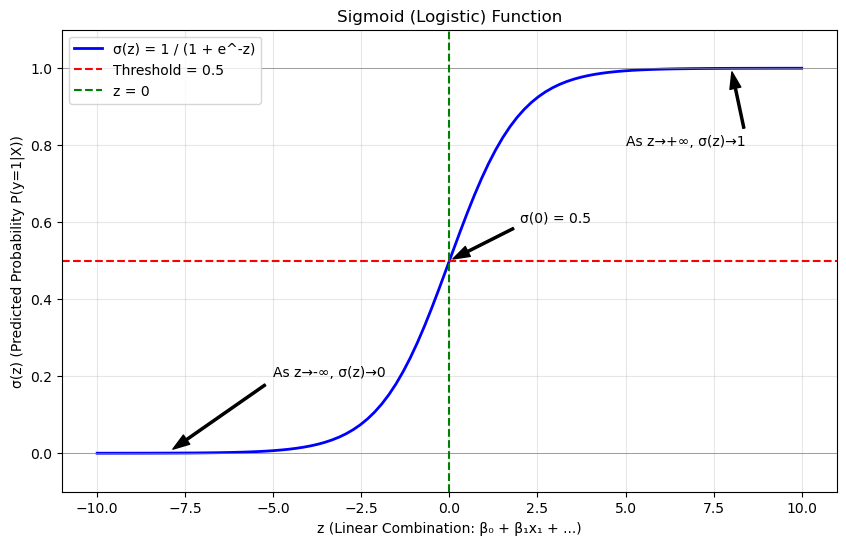

In [3]:
# Visualizing the sigmoid function
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    """Computes the sigmoid function."""
    return 1 / (1 + np.exp(-z))

# Generate values for z
z = np.linspace(-10, 10, 100)
# Calculate corresponding sigmoid values
sigma_z = sigmoid(z)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(z, sigma_z, label='σ(z) = 1 / (1 + e^-z)', color='blue', linewidth=2)
plt.axhline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.axhline(0, color='gray', linestyle='-', linewidth=0.5)
plt.axhline(1, color='gray', linestyle='-', linewidth=0.5)
plt.axvline(0, color='green', linestyle='--', label='z = 0')
plt.xlabel("z (Linear Combination: β₀ + β₁x₁ + ...)")
plt.ylabel("σ(z) (Predicted Probability P(y=1|X))")
plt.title("Sigmoid (Logistic) Function")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)  # Set y-axis limits slightly beyond 0 and 1

# Annotate key points
plt.annotate('σ(0) = 0.5', xy=(0, 0.5), xytext=(2, 0.6),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))
plt.annotate('As z→+∞, σ(z)→1', xy=(8, 0.999), xytext=(5, 0.8),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))
plt.annotate('As z→-∞, σ(z)→0', xy=(-8, 0.001), xytext=(-5, 0.2),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))

plt.show()

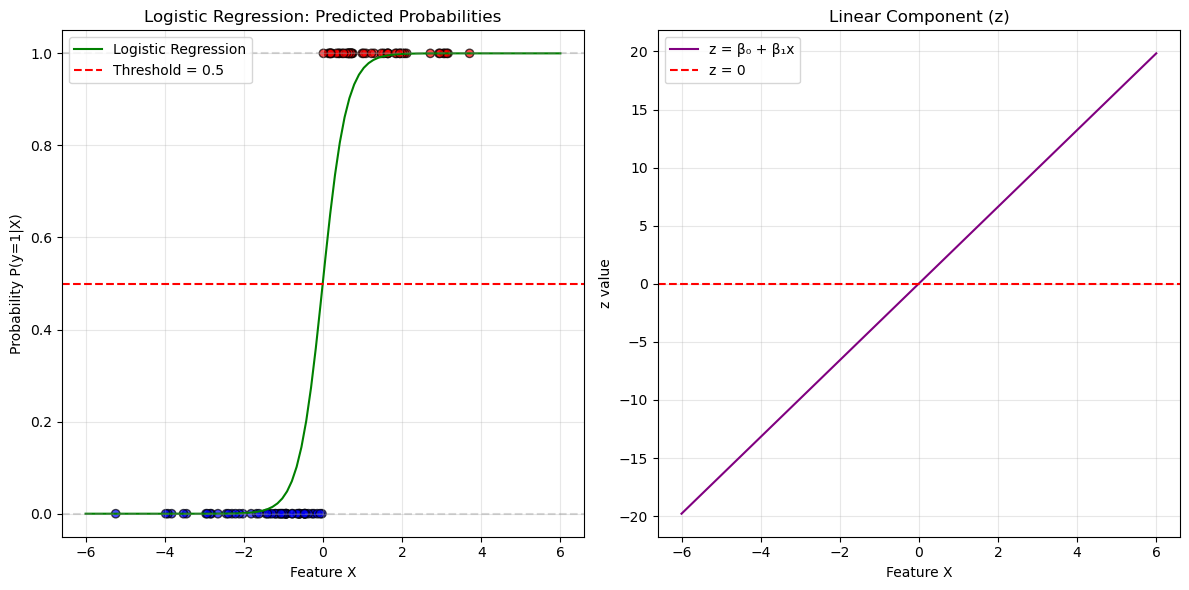

In [4]:
# Complete illustration combining linear component and sigmoid
plt.figure(figsize=(12, 6))

# Data points for binary classification (same as before)
np.random.seed(42)
X = np.random.randn(100, 1) * 2  # Feature
y = (X.squeeze() > 0).astype(int)  # Binary target (0 or 1)

# Fit logistic regression (manually for illustration)
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X, y)

# Get parameters
beta_0 = log_reg.intercept_[0]
beta_1 = log_reg.coef_[0][0]

# Compute z and sigmoid(z) across the range
X_range = np.linspace(-6, 6, 100).reshape(-1, 1)
z = beta_0 + beta_1 * X_range.squeeze()
sigmoid_z = sigmoid(z)

# Plot setup
plt.subplot(1, 2, 1)
plt.scatter(X, y, c=y, cmap='bwr', edgecolor='k', alpha=0.7)
plt.plot(X_range, sigmoid_z, color='green', label='Logistic Regression')
plt.axhline(y=0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.3)
plt.title('Logistic Regression: Predicted Probabilities')
plt.xlabel('Feature X')
plt.ylabel('Probability P(y=1|X)')
plt.grid(alpha=0.3)
plt.legend()

# Plot the linear component (z) separately
plt.subplot(1, 2, 2)
plt.plot(X_range, z, color='purple', label='z = β₀ + β₁x')
plt.axhline(y=0, color='red', linestyle='--', label='z = 0')
plt.title('Linear Component (z)')
plt.xlabel('Feature X')
plt.ylabel('z value')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

<!-- Placeholder for sigmoid function visualization -->
<!-- Figure 2: Visualization of the sigmoid function showing its S-shape and key properties -->

<!-- Placeholder for logistic regression vs linear component visualization -->
<!-- Figure 3: Side-by-side comparison of logistic regression predictions and the underlying linear component -->

> **Knowledge Check**: What happens when the output of our linear equation (z) is exactly 0? What probability does the sigmoid function give us?
> 
> *Answer: When z = 0, the sigmoid function outputs exactly 0.5, which corresponds to a 50% probability that the input belongs to class 1. This is often used as the default decision boundary.*

## 3.2.2 Decision Boundary & Thresholding

### From Probability to Class

Logistic Regression outputs a probability between 0 and 1. To make a definite class prediction (e.g., 0 or 1), we need a **decision threshold**.

### Standard Threshold

The most common threshold is **0.5**:
- If $P(y=1|X) \geq 0.5$, predict class 1
- If $P(y=1|X) < 0.5$, predict class 0

### Decision Boundary

The threshold corresponds to a boundary in the feature space that separates the predicted classes:

- When $P(y=1|X) = 0.5$, this happens when the input to the sigmoid function is $z = 0$
- Therefore, the decision boundary is defined by the equation: $\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p = 0$

**Linear Boundary:** Notice that this equation is *linear* in terms of the features $(x_1, x_2, ...)$. This means Logistic Regression creates a **linear decision boundary** (a line in 2D, a plane in 3D, a hyperplane in higher dimensions).

C:\Users\solom\AppData\Local\Temp\ipykernel_24620\1092203879.py:30: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, Z, [0.5], colors='red', linewidths=2, label='Decision Boundary')


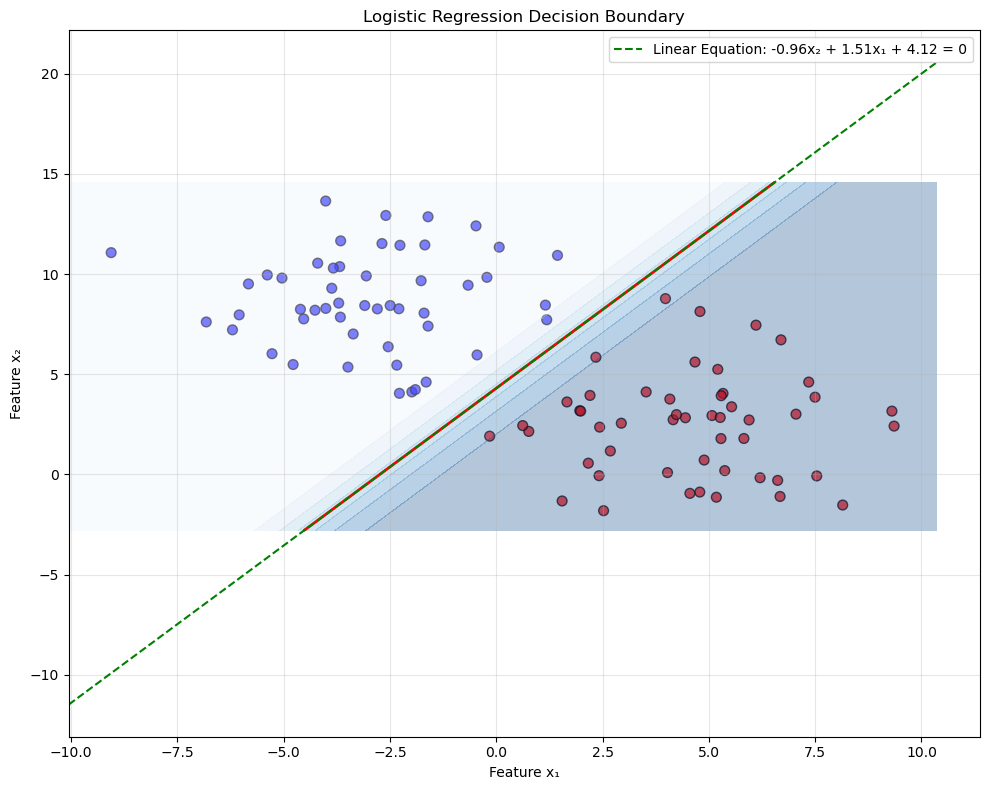

In [5]:
# Visualizing decision boundary in 2D
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_blobs

# Generate a more interesting 2D dataset
X, y = make_blobs(n_samples=100, centers=2, n_features=2, random_state=42, cluster_std=2.5)

# Fit logistic regression
log_reg = LogisticRegression()
log_reg.fit(X, y)

# Plot the data points
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', s=50, alpha=0.7)

# Create a meshgrid to visualize the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict probabilities on the meshgrid
Z = log_reg.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Plot the decision boundary and probability contours
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Blues')
plt.contour(xx, yy, Z, [0.5], colors='red', linewidths=2, label='Decision Boundary')

# Get the coefficients to plot the equation
coef = log_reg.coef_[0]
intercept = log_reg.intercept_[0]
slope = -coef[0] / coef[1]
intercept_plot = -intercept / coef[1]

# Add the linear equation to the plot
x_boundary = np.array([x_min, x_max])
y_boundary = slope * x_boundary + intercept_plot
plt.plot(x_boundary, y_boundary, color='green', linestyle='--', 
         label=f'Linear Equation: {coef[1]:.2f}x₂ + {coef[0]:.2f}x₁ + {intercept:.2f} = 0')

plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Feature x₁')
plt.ylabel('Feature x₂')
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

C:\Users\solom\AppData\Local\Temp\ipykernel_24620\2144080743.py:10: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, Z, [threshold], colors=color, linewidths=2,
C:\Users\solom\AppData\Local\Temp\ipykernel_24620\2144080743.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


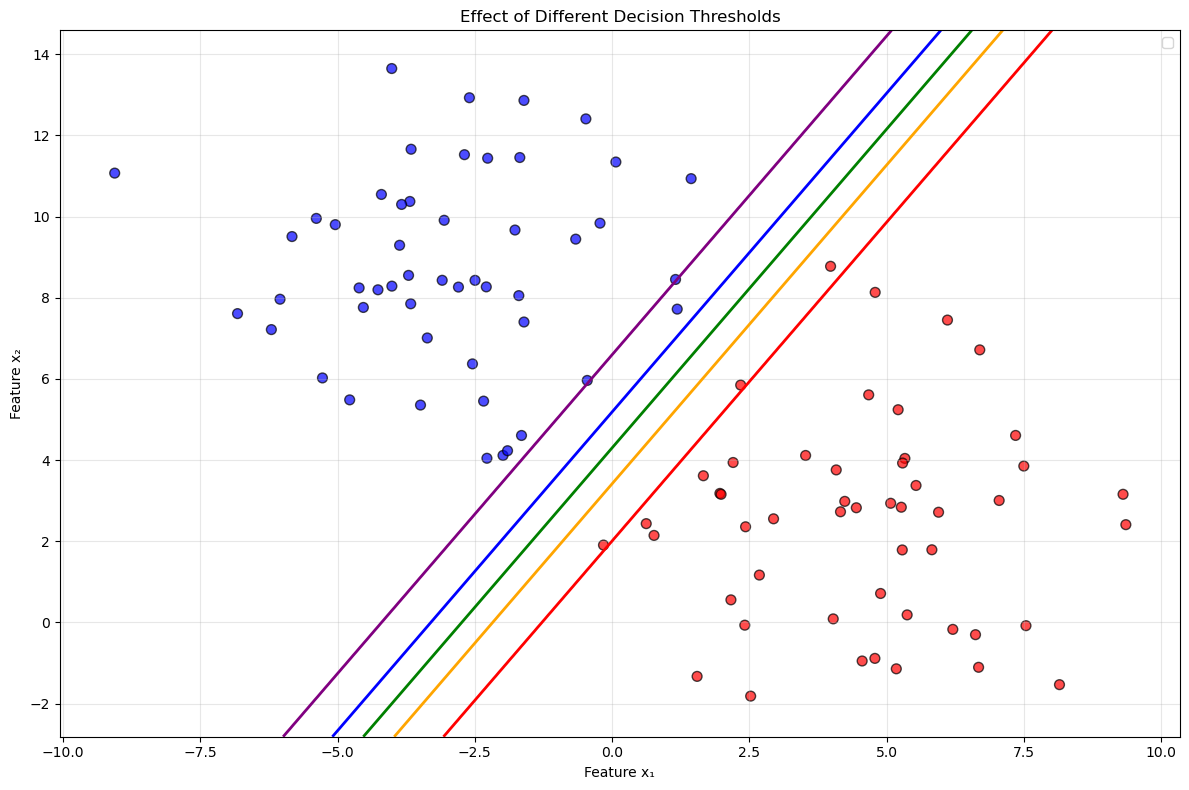

In [6]:
# Add visualization of different thresholds
plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', s=50, alpha=0.7)

# Plot multiple threshold contours
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
colors = ['purple', 'blue', 'green', 'orange', 'red']

for threshold, color in zip(thresholds, colors):
    plt.contour(xx, yy, Z, [threshold], colors=color, linewidths=2, 
                label=f'Threshold = {threshold}')

plt.title('Effect of Different Decision Thresholds')
plt.xlabel('Feature x₁')
plt.ylabel('Feature x₂')
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

<!-- Placeholder for decision boundary visualization -->
<!-- Figure 4: Visualization of the linear decision boundary separating two classes in a 2D feature space -->

<!-- Placeholder for multiple thresholds visualization -->
<!-- Figure 5: Effect of different decision thresholds on the classification boundary -->

### Adjusting the Threshold

While 0.5 is the standard threshold, it can be adjusted depending on the specific problem and the relative costs of different types of errors:

- **False Positives (Type I errors)**: Predicting class 1 when it's actually class 0
- **False Negatives (Type II errors)**: Predicting class 0 when it's actually class 1

**Considerations for Threshold Adjustment:**

1. **Imbalanced Datasets**: When one class is much more common than the other, the default threshold might not be optimal.

2. **Different Error Costs**: In some domains, certain types of errors are more costly than others.
   - Medical diagnosis: False negatives (missing a disease) might be more critical than false positives
   - Spam filtering: False positives (marking legitimate emails as spam) might be more problematic than false negatives

3. **Performance Metrics**: Different thresholds optimize different metrics (precision, recall, F1-score, etc.)

> **Real-World Application**: In credit card fraud detection, false negatives (failing to detect actual fraud) can be very costly for the bank, while false positives (flagging legitimate transactions as fraud) cause inconvenience to customers. The threshold is often lowered to catch more fraud cases, accepting some additional false alarms.

### Preview of ROC Curves

The trade-off between different types of errors at various thresholds can be visualized using a Receiver Operating Characteristic (ROC) curve, which we'll cover in more detail when discussing evaluation metrics.

In [2]:
# Brief preview of ROC curve
from sklearn.metrics import roc_curve, auc

# Get predictions on the test set
y_proba = log_reg.predict_proba(X)[:, 1]
fpr, tpr, thresholds = roc_curve(y, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Preview')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Mark a few threshold points
threshold_indices = [10, 30, 50, 70, 90]  # Example indices
for i in threshold_indices:
    if i < len(thresholds):
        plt.plot(fpr[i], tpr[i], 'o', markersize=8, 
                label=f'Threshold ≈ {thresholds[i]:.2f}')

plt.legend()
plt.show()

NameError: name 'log_reg' is not defined

<!-- Placeholder for ROC curve visualization -->
<!-- Figure 6: Preview of ROC curve showing the trade-off between true positive rate and false positive rate at different thresholds -->

## 3.2.3 Learning the Model Parameters

Similar to Linear Regression, Logistic Regression needs to find the optimal values for the coefficients $(\beta_0, \beta_1, ...)$. This is typically done by:

1. **Defining a Cost Function**: Unlike linear regression which uses Mean Squared Error, logistic regression uses **Log Loss** (also called Binary Cross-Entropy):

   $$J(\beta) = -\frac{1}{n} \sum_{i=1}^{n} [y_i \log(p_i) + (1-y_i) \log(1-p_i)]$$

   where $p_i$ is the predicted probability that the $i$-th sample belongs to class 1.

2. **Minimizing the Cost Function**: This is typically done using optimization algorithms like Gradient Descent.

The log loss function has some key properties:
- It heavily penalizes confident wrong predictions
- It approaches infinity as the predicted probability approaches 0 for a positive example or 1 for a negative example

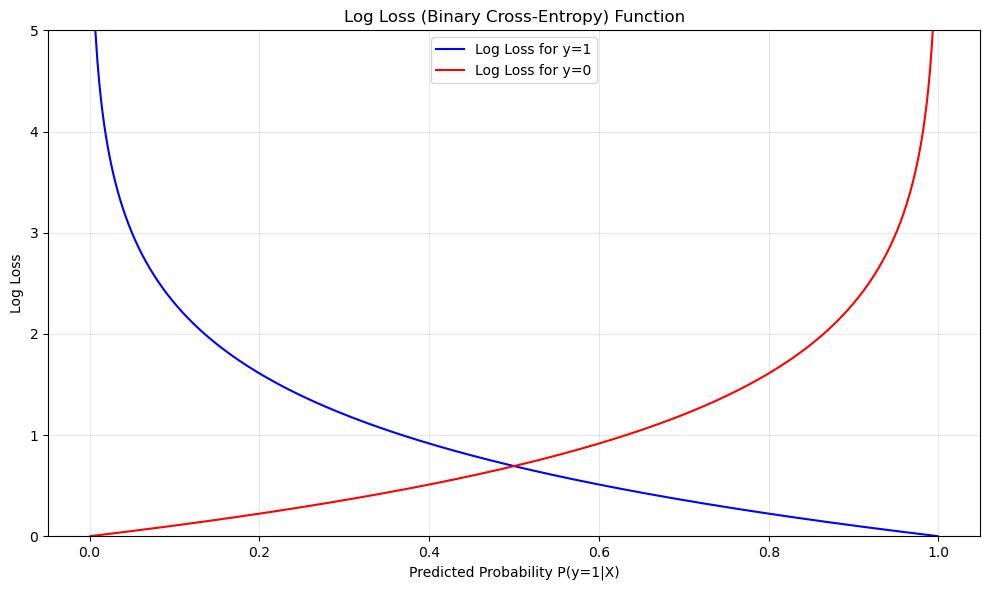

In [4]:
# Visualizing the log loss (binary cross-entropy) function
import numpy as np
import matplotlib.pyplot as plt

def log_loss_for_one_example(y_true, y_pred):
    """Compute log loss for a single example."""
    epsilon = 1e-15  # Small constant to avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # Clip predictions to avoid numerical issues
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Range of predicted probabilities
y_pred_range = np.linspace(0.001, 0.999, 1000)

# Compute log loss for a positive example (y=1)
log_loss_positive = log_loss_for_one_example(1, y_pred_range)

# Compute log loss for a negative example (y=0)
log_loss_negative = log_loss_for_one_example(0, y_pred_range)

# Plot the log loss function
plt.figure(figsize=(10, 6))
plt.plot(y_pred_range, log_loss_positive, label='Log Loss for y=1', color='blue')
plt.plot(y_pred_range, log_loss_negative, label='Log Loss for y=0', color='red')
plt.xlabel('Predicted Probability P(y=1|X)')
plt.ylabel('Log Loss')
plt.title('Log Loss (Binary Cross-Entropy) Function')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 5)  # Limit y-axis for better visualization
plt.tight_layout()
plt.show()

<!-- Placeholder for log loss function visualization -->
<!-- Figure 7: Log loss function for positive and negative examples, showing how it penalizes confident wrong predictions -->

## 3.2.4 Strengths and Limitations

### Strengths of Logistic Regression

1. **Simplicity**: Easy to implement, train, and interpret
2. **Efficiency**: Trains quickly, even on large datasets
3. **Probabilistic Output**: Provides probability estimates, not just classifications
4. **Regularization**: Can handle multicollinearity with L1/L2 regularization
5. **Online Learning**: Can be updated incrementally with new data

### Limitations of Logistic Regression

1. **Linear Decision Boundary**: Cannot capture complex, non-linear relationships without feature engineering
2. **Feature Independence**: Assumes features are independent (though this can be addressed with interaction terms)
3. **Limited to Classification**: Cannot be used directly for regression tasks
4. **Binary Output**: Basic form is for binary classification (though it can be extended to multiclass)
5. **Data Assumptions**: Works best when classes are linearly separable

> **Knowledge Check**: How does logistic regression differ from linear regression in terms of:
> 1. The output it produces?
> 2. The cost function it uses?
> 3. The type of decision boundary it creates?
>
> *Answers:*
> *1. Linear regression outputs continuous values, while logistic regression outputs probabilities between 0 and 1.*
> *2. Linear regression typically uses Mean Squared Error as its cost function, while logistic regression uses Log Loss (Binary Cross-Entropy).*
> *3. Both create linear boundaries, but logistic regression converts this to a probability via the sigmoid function, and then applies a threshold for classification.*

Next, we'll implement Logistic Regression on a real dataset and see how it performs in practice.